In [46]:
import sys
sys.path.append('../')

In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.nn import functional as F
import os
import tqdm

import einops
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import torchvision.transforms as transforms

from utils.root_path import results_reconstructions_path, ultrasound_path
from utils.get_reconstruction_imgs import get_images_for_reconstruction_fetal_abdominal, get_images_for_reconstruction_xray_mimic200, get_images_for_reconstruction_crc
from utils.load_real_img import load_real_img_fetalAbdominal, load_real_img_mimic200, load_real_img_crc

In [ ]:
dataset = "XRayMimic200"
results_reconstructions_path = "/local/scratch/clmn1/fednca_journal/reconstructions"

known_label_options = [True, False]
if dataset == "fetalAbdominal":
    images = get_images_for_reconstruction_fetal_abdominal()
    load_real_image = load_real_img_fetalAbdominal
    seg_models = [
        ("unet", "l2_normalized"),
        ("segformer", "l2"),
        ("transunet_b16", "l2"),
        ("new_mednca", "l2_normalized"),
        ("deterministic_mednca", "l2_normalized")
    ]
elif dataset == "XRayMimic200":
    images = get_images_for_reconstruction_xray_mimic200()
    load_real_image = load_real_img_mimic200
    seg_models = [
        ("unet", "l2_normalized"),
        ("segformer", "l2"),
        ("transunet_b16", "l2"),
        ("new_mednca", "l2_normalized"),
        ("deterministic_mednca", "l2_normalized")
    ]
elif dataset == "crc":
    results_reconstructions_path = "/local/scratch/mikonsta/fednca_journal/reconstructions"
    images = get_images_for_reconstruction_crc()
    load_real_image = load_real_img_crc
    seg_models = [
        ("vit4sgd", "l2"),
        ("densenet", "l2"),
        ("maxmednca_nobn", "l2_normalized"),
        ("deterministic_maxmednca_nobn", "l2_normalized"),
    ]

In [49]:
def rename_model(model_name):
    if model_name == "unet":
        return "UNet"
    elif model_name == "segformer":
        return "SegFormer"
    elif model_name == "transunet_b16":
        return "TransUNet"
    elif model_name == "new_mednca":
        return "FedNCA"
    elif model_name == "deterministic_mednca":
        return "FedNCA (det)"
    elif model_name == "vit":
        return "ViT"
    elif model_name == "resnet18":
        return "ResNet18"
    elif model_name == "cnn":
        return "CNN"
    elif model_name == "deterministic_maxmednca":
        return "FedNCA (det)"
    elif model_name == "maxmednca":
        return "FedNCA"
    elif model_name == "vit4sgd":
        return "ViT"
    elif model_name == "densenet":
        return "DenseNet"
    elif model_name == "maxmednca_nobn":
        return "FedNCA"
    elif model_name == "deterministic_maxmednca_nobn":
        return "FedNCA (det)"
    else:
        print(f"Unknown model name: {model_name}")
        return model_name

In [50]:
seed = 42
num_samples = 4
np.random.seed(seed)
sub_images = np.random.choice(images, size=num_samples, replace=False)
print("Selected images for reconstruction visualization:", sub_images)

Selected images for reconstruction visualization: ['0e4d1fed-933a642c-5cef449a-c51dea63-c3772d59'
 '2ff05b3d-12157122-57d55a45-0bee784f-41248fdd'
 '2d4514ff-90139e49-4d2d6efe-94a3df89-dbdaf026'
 '3ac730f8-3d53c07c-6057ac79-7fe11713-bbf15bee']


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 206.46it/s]
/tmp/ipykernel_2406176/3560877887.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


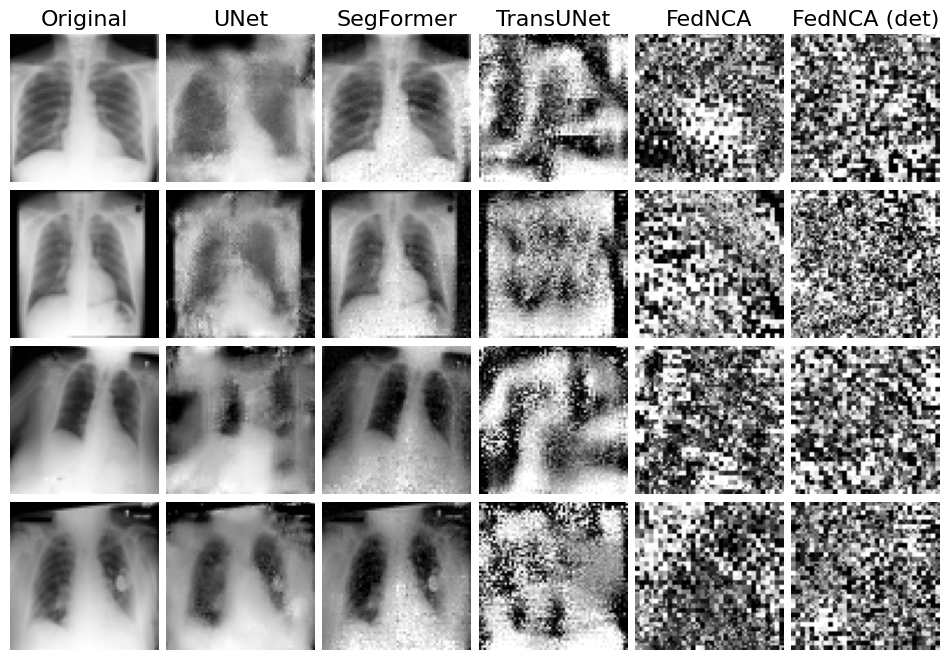

In [51]:
known_label = False

plt.figure(figsize=(2 * (len(seg_models)+1), 2*len(sub_images)))
gs1 = gridspec.GridSpec(len(sub_images), len(seg_models)+1) # create a grid for subplots
gs1.update(wspace=0.05, hspace=0.05) # set the spacing between axes.

for img_name in sub_images:
    real_x, real_y = load_real_image(img_name)
    plt.subplot(gs1[ list(sub_images).index(img_name)*(len(seg_models)+1) ])
    if len(real_x.shape) == 3:
        real_x = einops.rearrange(real_x, 'c h w -> h w c')
    plt.imshow(real_x, cmap='gray')
    plt.axis('off')
    if list(sub_images).index(img_name) == 0:
        plt.title("Original", fontsize=16)
    for model, distance in tqdm.tqdm(seg_models):
        path = os.path.join(results_reconstructions_path, f"{dataset}/{model}/{known_label}_{distance}/{img_name.replace('/', '_')}")
        fake_x = Image.open(os.path.join(path, "reconstruction.png"))
        plt.subplot(gs1[ 1 + list(sub_images).index(img_name)*(len(seg_models)+1) + seg_models.index((model, distance)) ])
        plt.imshow(fake_x, cmap='gray')
        plt.axis('off')
        if list(sub_images).index(img_name) == 0:
            plt.title(rename_model(model), fontsize=16)

plt.subplots_adjust(wspace=0, hspace=0)
plt.margins(0,0)
plt.tight_layout()
plt.savefig(f'./reconstructions_{dataset}_knownLabel{known_label}_{seed}.pdf', dpi=300, bbox_inches='tight')